# Burgers equation in 1 dimension

Authored by Aleksei G. Sorokin

## Setup

In [1]:
import glob 
import os
import sys; 
sys.path.append("../")

In [2]:
import fastgps
import chonknoris
import gpytorch
import torch
import lightning
import qmcpy as qp
import numpy as np

In [3]:
torch.set_default_dtype(torch.float64)
assert torch.cuda.is_available()
DEVICE = "cuda:3"

In [4]:
ROOT = "."
assert os.path.isfile(ROOT+"/burgers_1d.ipynb")

In [6]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)

## Reference Data 

### Parameters

In [7]:
NU = 0.02
P = 3
R = 2**9
GHDEG = 350
Nx = 127
Nt = 151
nticks = Nx*Nt
xticks = torch.linspace(-1,1,Nx+2)[1:-1]
tticks = torch.linspace(0,1,Nt)
dx = xticks[1]-xticks[0]
dt = tticks[1]-tticks[0]
print(xticks)
print(tticks)

tensor([-0.9844, -0.9688, -0.9531, -0.9375, -0.9219, -0.9062, -0.8906, -0.8750,
        -0.8594, -0.8438, -0.8281, -0.8125, -0.7969, -0.7812, -0.7656, -0.7500,
        -0.7344, -0.7188, -0.7031, -0.6875, -0.6719, -0.6562, -0.6406, -0.6250,
        -0.6094, -0.5938, -0.5781, -0.5625, -0.5469, -0.5312, -0.5156, -0.5000,
        -0.4844, -0.4688, -0.4531, -0.4375, -0.4219, -0.4062, -0.3906, -0.3750,
        -0.3594, -0.3438, -0.3281, -0.3125, -0.2969, -0.2812, -0.2656, -0.2500,
        -0.2344, -0.2188, -0.2031, -0.1875, -0.1719, -0.1562, -0.1406, -0.1250,
        -0.1094, -0.0938, -0.0781, -0.0625, -0.0469, -0.0312, -0.0156,  0.0000,
         0.0156,  0.0312,  0.0469,  0.0625,  0.0781,  0.0938,  0.1094,  0.1250,
         0.1406,  0.1562,  0.1719,  0.1875,  0.2031,  0.2188,  0.2344,  0.2500,
         0.2656,  0.2812,  0.2969,  0.3125,  0.3281,  0.3438,  0.3594,  0.3750,
         0.3906,  0.4062,  0.4219,  0.4375,  0.4531,  0.4688,  0.4844,  0.5000,
         0.5156,  0.5312,  0.5469,  0.56

### Generate $u$

u.shape = (512, 127)


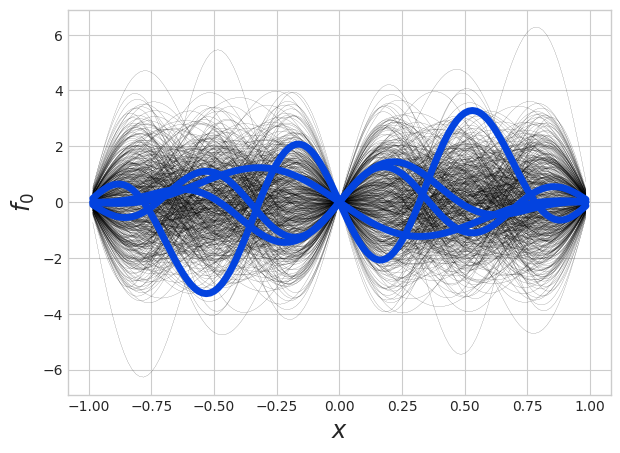

In [8]:
a = torch.from_numpy(qp.Gaussian(qp.DigitalNetB2(P,seed=7)).gen_samples(R))
k = torch.arange(1,P+1)
def u_func(x):
    y = a[:,:,None]*torch.sin(torch.pi*k[:,None]*x)
    return y.sum(1)
u = u_func(xticks.cpu()).to(DEVICE)
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(7,5))
ax.set_ylabel(r"$f_0$",fontsize="xx-large")
ax.set_xlabel(r"$x$",fontsize="xx-large")
ax.plot(xticks.cpu(),u.T.cpu(),linewidth=.1,color="k")
for j in range(4):
    ax.plot(xticks.cpu(),u[j].cpu(),linewidth=5,color=COLORS[0])
print("u.shape = %s"%str(tuple(u.shape)))


### Compute $v$ from Cole-Hopf transform

In [9]:
def f_func(x):
    y = -1/(2*NU*torch.pi*k.cpu()[:,None])*a.cpu()[:,:,None]*(torch.cos(torch.pi*k.cpu()[:,None])-torch.cos(k.cpu()[:,None]*torch.pi*x.cpu()))
    return torch.exp(y.sum(1))
tmesh,xmesh = torch.meshgrid(tticks.cpu(),xticks.cpu(),indexing="ij")
ticks = torch.vstack([tmesh.flatten(),xmesh.flatten()]).T
gh_pts,gh_weights = np.polynomial.hermite.hermgauss(GHDEG) 
gh_pts,gh_weights = torch.from_numpy(gh_pts).to("cpu"),torch.from_numpy(gh_weights).to("cpu")
etamesh = xmesh[:,:,None]-torch.sqrt(4*NU*tmesh[:,:,None])*gh_pts
fmesh = f_func(etamesh.flatten().cpu()).reshape((-1,*etamesh.shape))
denom = (fmesh*gh_weights).sum(-1)
numer = (fmesh*gh_pts/torch.sqrt(tmesh[:,:,None])*gh_weights).sum(-1)
vref = np.sqrt(4*NU)*numer/denom
vref[:,0,:] = u
xticks_ext = xticks*1.5-.25
f = f_func(xticks_ext)

v.shape = (512, 151, 127)


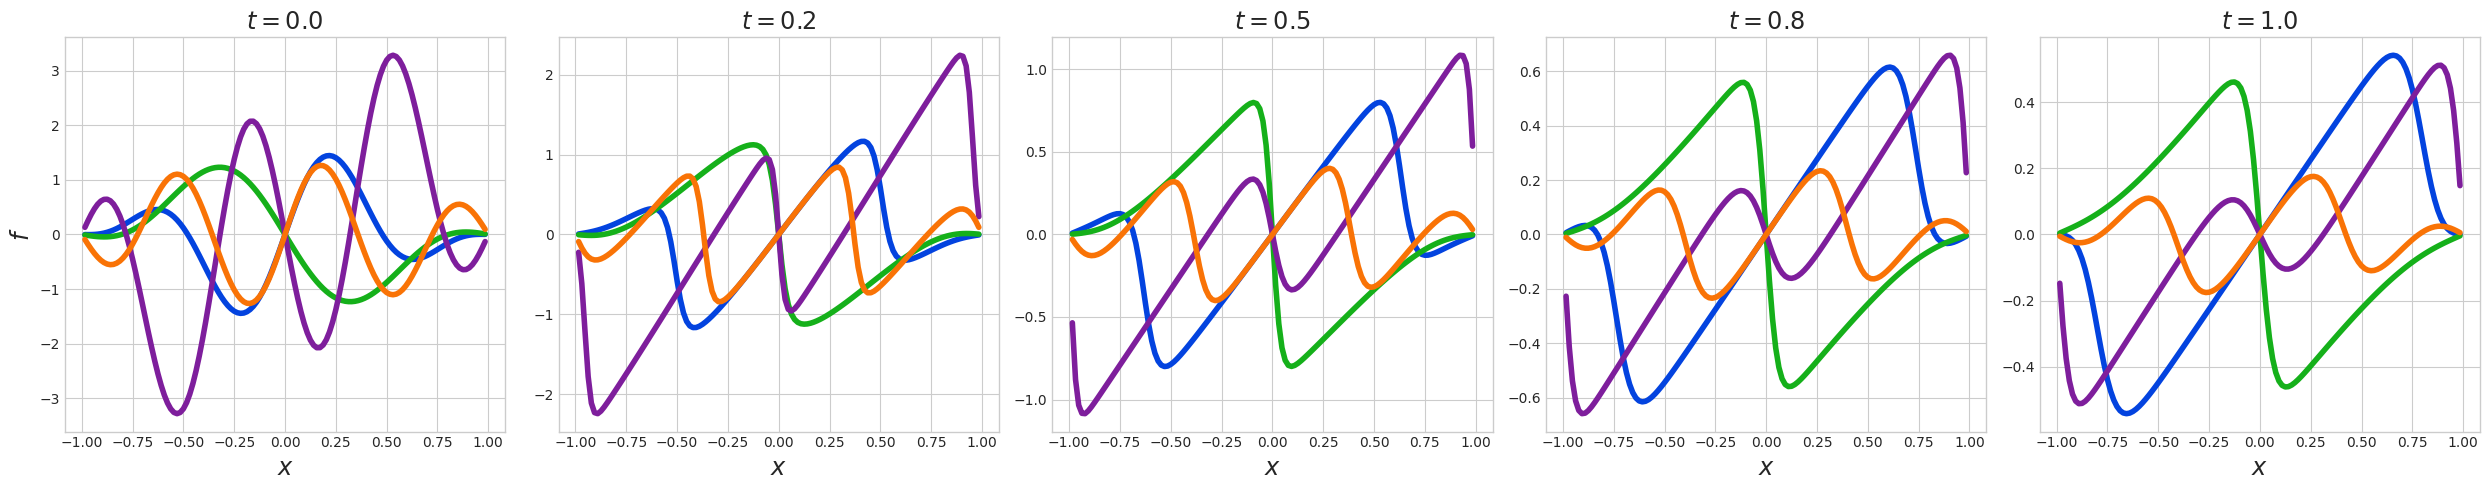

In [10]:
tpltidxs = [0,Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = pyplot.subplots(nrows=1,ncols=len(tpltidxs),figsize=(5*len(tpltidxs),5))
for i,tiplt in enumerate(tpltidxs):
    ax[i].set_title(r"$t = %.1f$"%tticks[tiplt],fontsize="xx-large")
    for j in range(4):
        ax[i].plot(xticks.cpu(),vref[j,tiplt,:],color=COLORS[j],linewidth=4)
    ax[i].set_xlabel(r"$x$",fontsize="xx-large")
ax[0].set_ylabel(r"$f$",fontsize="xx-large")
print("v.shape = %s"%str(tuple(vref.shape)))
fig.tight_layout()
fig.savefig("out/cole_hopf_solutions.pdf")

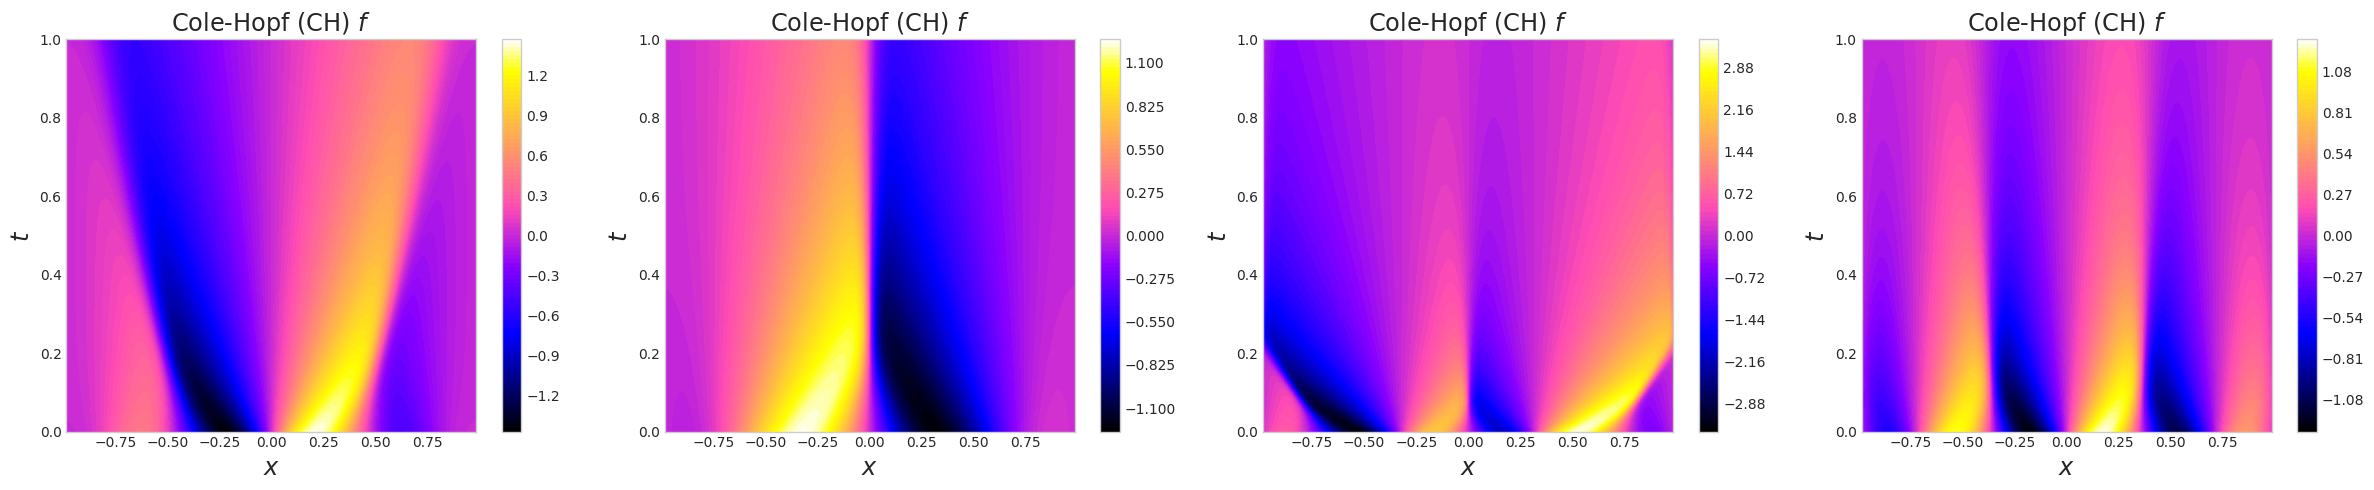

In [11]:
fig,ax = chonknoris.plot_contourfs(
    data = [
        [(xmesh,tmesh,vref[i]) for i in range(4)],
    ],
    xlabels=r"$x$",
    ylabels=r"$t$",
    titles=r"Cole-Hopf (CH) $f$",
    cmap = "gnuplot2",
)

### Gauss Newton Solver

In [12]:
def pde_solve(
        u, 
        v0_pred = None, 
        num_newton_iter = 6, 
        relaxation = 0, 
        lr = 1, 
        line_search = False, 
        line_search_c1 = 1e-4, 
        line_search_beta = .3,
        line_search_min_lr = 1e-16,
        laplace_wraparound = False,
        deriv_wraparound = False,
        vref = None, 
        predict_Linvs = None, 
        store_Linvs = False, 
        verbose = True,
        vverbose = True,
        verbose_indent = 4):
    times = torch.empty(num_newton_iter+1)
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    assert u.ndim==2 and u.size(1)==Nx
    assert vref is None or vref=="last" or isinstance(vref,torch.Tensor)
    R = len(u) # number of realizations
    Nxrange = torch.arange(Nx,device=DEVICE)
    # A_laplace.shape == (Nx,Nx)
    A_laplace = torch.zeros((Nx,Nx),device=DEVICE)
    A_laplace[Nxrange,Nxrange] = -2 
    A_laplace[Nxrange[1:],Nxrange[:-1]] = 1
    A_laplace[Nxrange[:-1],Nxrange[1:]] = 1
    if laplace_wraparound:
        assert relaxation>0, "laplace_wraparound=True requires relaxation>0"
        assert line_search, "laplace_wraparound=True seems to only work when using line search"
        A_laplace[0,-1] = 1 
        A_laplace[-1,0] = 1
    A_laplace = A_laplace/dx**2
    # C_deriv.shape = (Nx,Nx)
    C_deriv = torch.zeros((Nx,Nx),device=DEVICE)
    C_deriv[Nxrange[:-1],Nxrange[1:]] = 1
    C_deriv[Nxrange[1:],Nxrange[:-1]] = -1
    if deriv_wraparound:
        C_deriv[0,-1] = -1
        C_deriv[-1,0] = 1
        assert relaxation>0, "deriv_wraparound=True requires relaxation>0"
        assert line_search, "deriv_wraparound=True seems to only work when using line search"
    C_deriv = C_deriv/(2*dx) 
    vs = torch.nan*torch.zeros((R,Nt,num_newton_iter+1,Nx))
    resid = torch.zeros((R,Nt,num_newton_iter+1,Nx))
    rmse_resid = torch.zeros((R,Nt,num_newton_iter+1))
    times = torch.zeros((Nt,num_newton_iter+1))
    if store_Linvs:
        Linvs = torch.zeros((R,Nt,num_newton_iter,Nx,Nx))
    if line_search:
        lr_lss = torch.zeros((R,Nt,num_newton_iter))
    if isinstance(vref,torch.Tensor):
        assert vref.shape==(R,Nt,Nx)
        # vref_norm.shape==(R,Nt)
        vrefnorm = torch.linalg.norm(vref,dim=2)
        l2rerrors = torch.zeros((R,Nt,num_newton_iter+1))
    vs[:,0,:,:] = u[:,None,:]
    for t in range(1,Nt):
        verbose_t = verbose and ((t+1)%vverbose==0 or t==(Nt-1))
        if verbose_t:
            _vstr = "time step %d of %d: t = %-15.2f"%(t+1,Nt,tticks[t])
            print(" "*verbose_indent+_vstr)
            print(" "*verbose_indent+"-"*len(_vstr))
            _vstr = "%-15s| %-10s| %-52s|"%("iter of %-6d"%num_newton_iter,"time","RMSE residual")
            if isinstance(vref,torch.Tensor):
                _vstr += " %-52s|"%"L2 relative error"
            print(" "*(verbose_indent+4)+_vstr)
            _vstr = "%-15s| %-10s| %-13s%-13s%-13s%-13s|"%(" "*15," "*10,"5%","median","mean","95%")
            if isinstance(vref,torch.Tensor):
                _vstr += " %-13s%-13s%-13s%-13s|"%("5%","median","mean","95%")
            print(" "*(verbose_indent+4)+_vstr)
            print(" "*(verbose_indent+4)+"-"*len(_vstr))
        # v.shape==u.shape==residual.shape==(R,Nx)
        if v0_pred is None:
            v = u.clone()
        else:
            v = v0_pred(u.clone())
        Cv = torch.einsum("ik,rk->ri",C_deriv,v)
        residual = u-(v-dt*NU*torch.einsum("ik,rk->ri",A_laplace,v)+dt*v*Cv) # u-P(v)
        for i in range(num_newton_iter+1):
            vs[:,t,i,:] = v.cpu()
            resid[:,t,i,:] = residual.cpu()
            rmse_resid[:,t,i] = torch.sqrt(torch.mean(residual**2,1)).cpu()
            if isinstance(vref,torch.Tensor):
                l2rerrors[:,t,i] = torch.linalg.norm(v-vref[:,t,:],dim=1)/vrefnorm[:,t]
            tend.record()
            torch.cuda.synchronize()
            times[t,i] = t0.elapsed_time(tend)/1000/R
            t0 = torch.cuda.Event(enable_timing=True)
            tend = torch.cuda.Event(enable_timing=True)
            t0.record()
            verbose_i = verbose and (i%verbose==0 or i==num_newton_iter)
            if verbose_i and verbose_t:
                _vstr = "%-15d| %-10.2e| %-13.2e%-13.2e%-13.2e%-13.2e|"%(i,times[t,i]*R,
                        torch.quantile(rmse_resid[:,t,i],.05),torch.quantile(rmse_resid[:,t,i],.5),torch.mean(rmse_resid[:,t,i]),torch.quantile(rmse_resid[:,t,i],.95))
                if isinstance(vref,torch.Tensor):
                    _vstr += " %-13.2e%-13.2e%-13.2e%-13.2e|"%(
                        torch.quantile(l2rerrors[:,t,i],.05),torch.quantile(l2rerrors[:,t,i],.5),torch.mean(l2rerrors[:,t,i]),torch.quantile(l2rerrors[:,t,i],.95))
                print(" "*(verbose_indent+4)+_vstr)
            if i==num_newton_iter: break
            # dPdv.shape == (R,Nx,Nx)
            dPdv = torch.tile(-dt*NU*A_laplace,(R,1,1))
            dPdv = dPdv+torch.einsum("rk,kl->rkl",v,dt*C_deriv)
            dPdv[:,Nxrange,Nxrange] = dPdv[:,Nxrange,Nxrange]+1+dt*Cv
            if predict_Linvs is None: 
                # Theta.shape==(R,Nx,Nx)
                Theta = torch.einsum("rki,rkj->rij",dPdv,dPdv) # batch dPdv[r].T@dPdv[r]
                Theta[:,Nxrange,Nxrange] = Theta[:,Nxrange,Nxrange]+relaxation # add to diagonals
                # L.shape==Linv.shape==(R,N,N)
                L = torch.linalg.cholesky(Theta,upper=False)
                Linv = torch.linalg.solve_triangular(L,torch.eye(Nx,device=DEVICE),upper=False)
            else:
                Linv = predict_Linvs(v)
            if store_Linvs:
                Linvs[:,t,i,:,:] = Linv.cpu()
            # b.shape==delta.shape==v_new.shape==residual.shape==(R,Nx)
            b = torch.einsum("rik,ri->rk",dPdv,residual)
            delta = torch.einsum("rik,ri->rk",Linv,torch.einsum("rik,rk->ri",Linv,b)) # batch Linv[r].T@(Linv[r]@b[r])
            v_new = v+lr*delta
            Cv_new = torch.einsum("ik,rk->ri",C_deriv,v_new)
            residual_new = u-(v_new-dt*NU*torch.einsum("ik,rk->ri",A_laplace,v_new)+dt*v_new*Cv_new) # u-P(v_new)
            if line_search:
                mask = torch.ones(R,dtype=bool,device=DEVICE)
                lr_ls = lr*torch.ones(R,device=DEVICE)
                _temp1 = torch.linalg.norm(residual,dim=1)**2
                _temp2 = 2*line_search_c1*(b*delta).sum(1)
                while True:
                    _mask = mask.clone()
                    mask[_mask] = (torch.linalg.norm(residual_new[_mask],dim=1)**2)>(_temp1[_mask]+lr_ls[_mask]*_temp2[_mask])
                    if mask.sum()==0 or lr_ls[mask].min()<=line_search_min_lr: break
                    lr_ls[mask] = lr_ls[mask]*line_search_beta
                    v_new[mask] = v[mask]+lr_ls[mask,None]*delta[mask]
                    Cv_new[mask] = torch.einsum("ik,rk->ri",C_deriv,v_new[mask])
                    residual_new[mask] = u[mask]-(v_new[mask]-dt*NU*torch.einsum("ik,rk->ri",A_laplace,v_new[mask])+dt*v_new[mask]*Cv_new[mask]) # u-P(v_new)
                lr_lss[:,t,i] = lr_ls.cpu()
            v = v_new
            Cv = Cv_new
            residual = residual_new
        u = v
    data = {"vs":vs,"resid":resid,"rmse_resid":rmse_resid,"times":torch.cumsum(times.flatten(),0).reshape((Nt,num_newton_iter+1))}
    if store_Linvs:
        data["Linvs"] = Linvs
    if line_search:
        data["lr_lss"] = lr_lss
    if vref=="last":
        vref = vs[:,:,-1,:]
        l2rerrors = torch.linalg.norm(vs-vref[:,:,None,:],dim=3)/torch.linalg.norm(vref[:,:,None,:],dim=3)
    if vref is not None:
        data["l2rerrors"] = l2rerrors
    return vs,data

In [13]:
vs,data = pde_solve(u,num_newton_iter=4,relaxation=0.,line_search=False,laplace_wraparound=False,deriv_wraparound=False,store_Linvs=True,vref=vref.to(DEVICE),verbose=1,vverbose=10)
Linvs = data["Linvs"]
for key,val in data.items():
    print('data["%s"].shape = %s'%(key,str(tuple(val.shape))))

    time step 10 of 151: t = 0.06           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 1.15e-03  | 5.19e-03     3.30e-02     4.19e-02     1.05e-01     | 1.37e-02     4.01e-02     4.32e-02     7.99e-02     |
        1              | 4.80e-02  | 1.62e-06     1.35e-04     7.56e-04     2.68e-03     | 2.33e-03     1.45e-02     1.82e-02     4.39e-02     |
        2              | 4.77e-02  | 4.18e-13     4.66e-09     7.56e-06     2.75e-06     | 2.33e-03     1.45e-02     1.83e-02     4.41e-02     |
        3              | 4.77e-02  | 5.6

### Train Test Split

In [14]:
(u_t,u_v,vs_t,vs_v,Linvs_t,Linvs_v),vidx = chonknoris.train_val_split(u,vs,Linvs,val_frac=1/8,shuffle=True,rng_shuffle_seed=7)
print("u_t.shape = %s"%str(tuple(u_t.shape)))
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
print()
print("u_v.shape = %s"%str(tuple(u_v.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# torch.save(
#     {
#         "u_t": u_t.cpu(),
#         "v_t": vs_t[:,:,-1,:].cpu(),
#         "u_v": u_v.cpu(),
#         "v_v": vs_v[:,:,-1,:].cpu(),
#     },
#     ROOT+"/out/burgers_pde_1d.data_Nt%dNx%d.train_val.pt"%(Nt,Nx))

u_t.shape = (448, 127)
vs_t.shape = (448, 151, 5, 127)
Linvs_t.shape = (448, 151, 4, 127, 127)

u_v.shape = (64, 127)
vs_v.shape = (64, 151, 5, 127)
Linvs_v.shape = (64, 151, 4, 127, 127)


### Plots

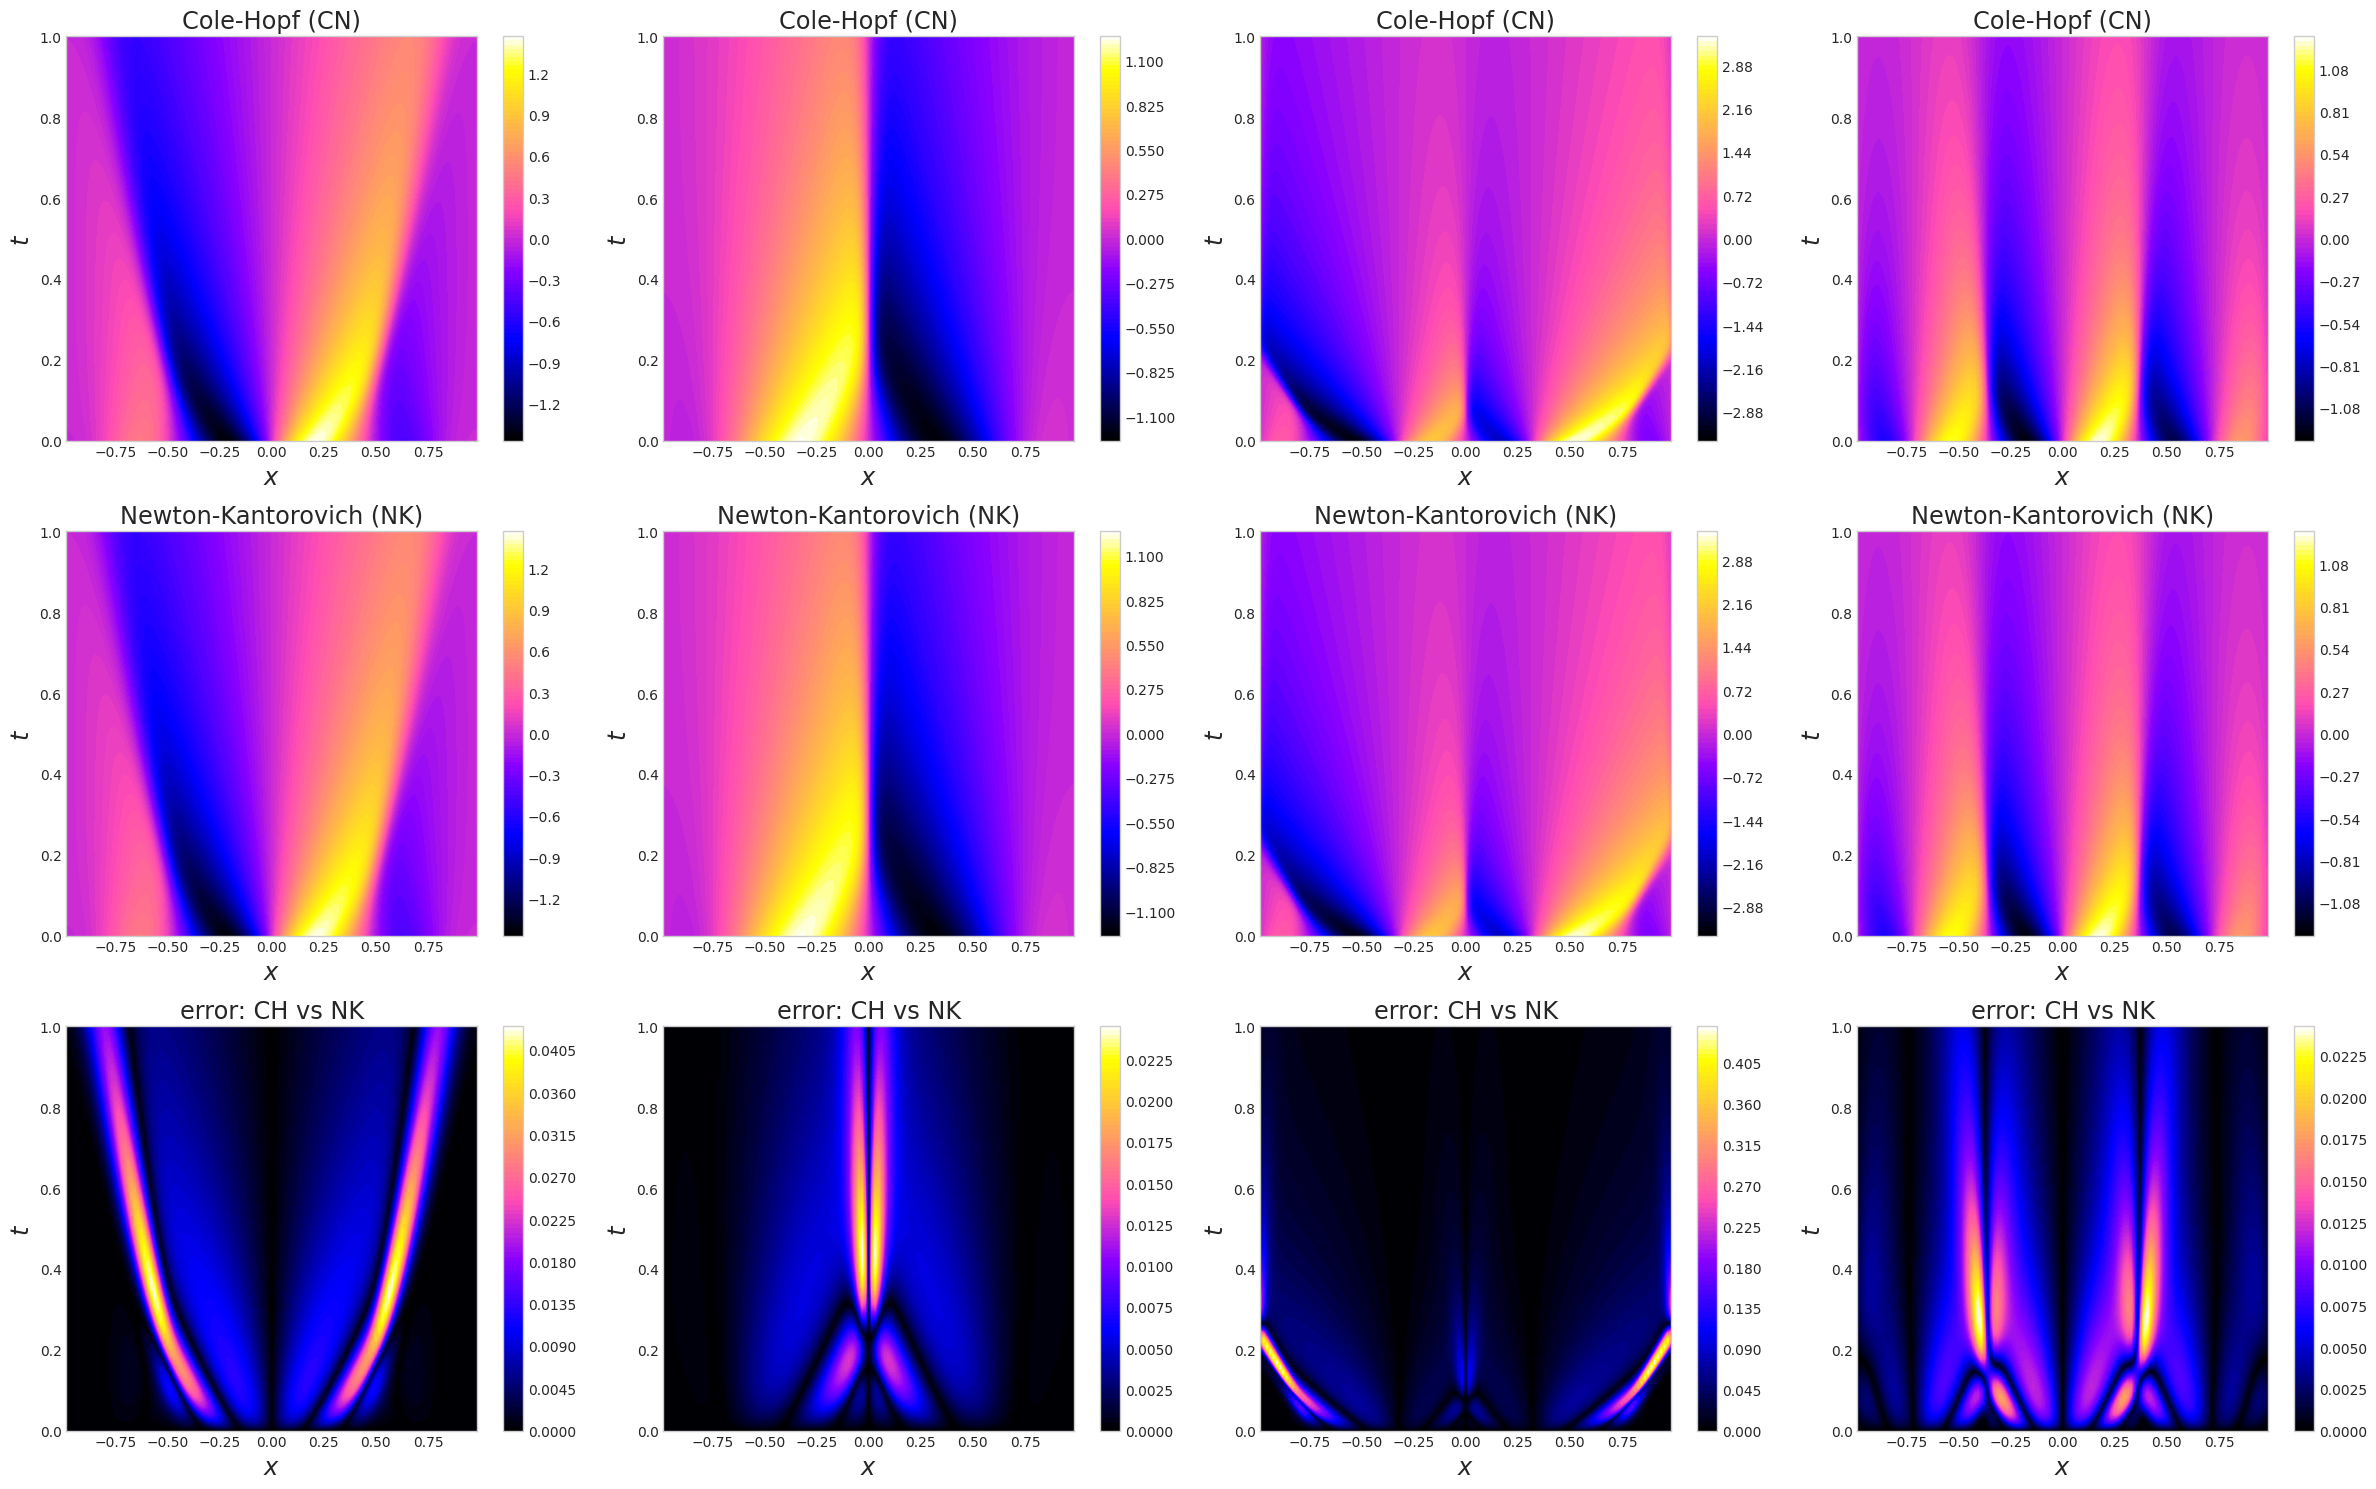

In [15]:
fig,ax = chonknoris.plot_contourfs(
    data = [
        [(xmesh,tmesh,vref[i]) for i in range(4)],
        [(xmesh,tmesh,vs[i,:,-1,:]) for i in range(4)],
        [(xmesh,tmesh,torch.abs(vs[i,:,-1,:]-vref[i])) for i in range(4)],
    ],
    titles=[[r"Cole-Hopf (CN)"],[r"Newton-Kantorovich (NK)"],[r"error: CH vs NK"]],
    xlabels = r"$x$",
    ylabels = r"$t$",
    cmap = "gnuplot2",
)

/data2/agsorok/CHONKNORIS/chonknoris/plots.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


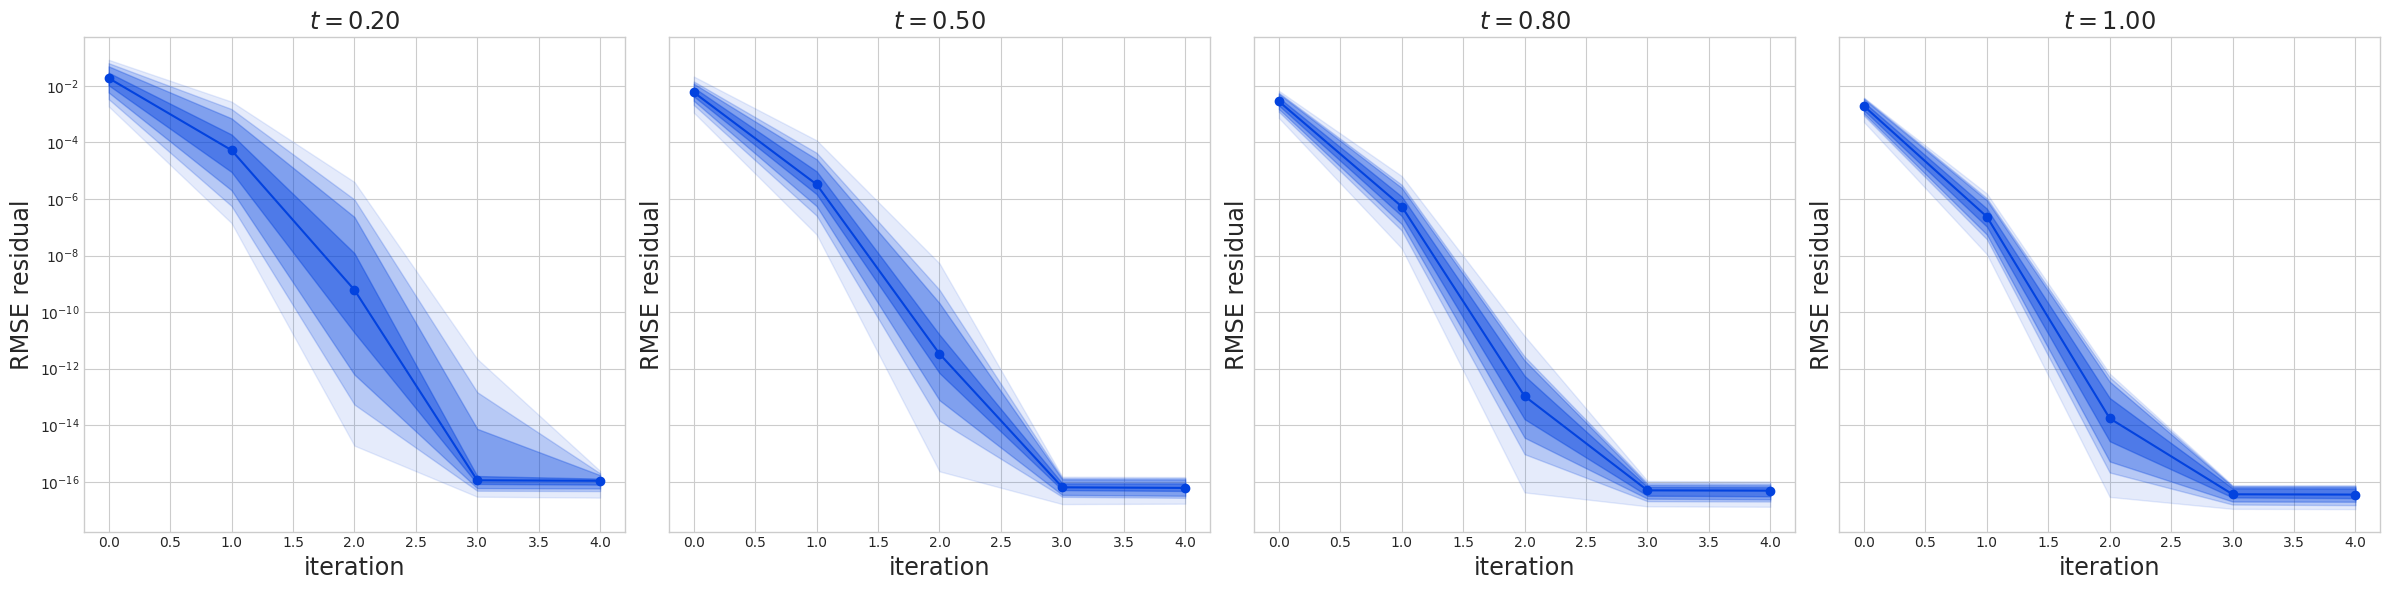

In [16]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmse_resid"][:,tiplt,:],None)] for tiplt in tpltidxs
        ],
        # [
        #     [(None,data["l2rerrors"][:,tiplt,:],None)] for tiplt in tpltidxs
        # ]
    ],
    xlogscale = False,
    ylogscale = True,
    colors=COLORS,
    sharex=True,
    sharey="row",
    xlabels = "iteration",
    ylabels = "RMSE residual",
        #    [r"$L_2$ relative error"]
    titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
    )
fig.savefig("out/convergence_nk_solver.pdf")

## CHONKNORIS Learning

In [17]:
relaxations = torch.tensor([.01])
SPARSE = False
if SPARSE:
    import pyKoLesky
    perm,sparse_lengths = pyKoLesky.cholesky.maximin(x=xticks[:,None],initial=torch.tensor([0.,1.])[:,None])
    sparse_pattern = pyKoLesky.cholesky.sparsity_pattern(xticks[:,None],lengths=sparse_lengths,rho=10)
    perm_inv = torch.argsort(perm) 
    print("sparsity reduction from %d elements to %d elements in Linv"%(
        Nx*(1+Nx)/2,sum(len(col_idxs) for col_idxs in sparse_pattern.values())))
else:
    sparse_pattern = None
    perm = perm_inv = torch.arange(Nx,device=DEVICE)

In [18]:
# takes a while to run
ds_Linv_t = chonknoris.DatasetLowerTriMatOpLearn(vs_t[:,1:,:-1].flatten(start_dim=0,end_dim=1),Linvs_t[:,1:].flatten(start_dim=0,end_dim=1),relaxations,sparse=SPARSE,sparse_perm=perm,sparse_pattern=sparse_pattern)
ds_Linv_v = chonknoris.DatasetLowerTriMatOpLearn(vs_v[:,1:,:-1].flatten(start_dim=0,end_dim=1),Linvs_v[:,1:].flatten(start_dim=0,end_dim=1),relaxations,sparse=SPARSE,sparse_perm=perm,sparse_pattern=sparse_pattern)
dl_Linv_t = torch.utils.data.DataLoader(ds_Linv_t,batch_size=2**8,collate_fn=tuple,shuffle=True)
dl_Linv_v = torch.utils.data.DataLoader(ds_Linv_v,batch_size=len(ds_Linv_v),collate_fn=tuple,shuffle=False)
print("len(ds_Linv_t) = %d"%len(ds_Linv_t))
print("len(ds_Linv_v) = %d"%len(ds_Linv_v))

len(ds_Linv_t) = 268800
len(ds_Linv_v) = 38400


### MLP

In [19]:
import gc
gc.collect()
torch.cuda.empty_cache()

save_dir = ROOT+"/logs/Linv_"+("SPARSE/" if SPARSE else "FULL/")
name = "MLP"
resume = True

if SPARSE:
  nn_Linv_mlp = chonknoris.MLP(mlp_layer_nodes=[Nx,150,250,350,len(ds_Linv_t._lti0)],activation_function=torch.nn.Tanh())
else:
  nn_Linv_mlp = chonknoris.MLP(mlp_layer_nodes=[Nx,500,1000,len(ds_Linv_t._lti0)],activation_function=torch.nn.Tanh())
lnn_Linv_mlp = chonknoris.LightningNN(nn_Linv_mlp,lr=1e-4,compute_l2errors=False,use_l2rerror_loss=False)
print(lnn_Linv_mlp)

csv_logger = lightning.pytorch.loggers.CSVLogger(save_dir=save_dir,name=name,version='csv')
trainer = lightning.Trainer(
    max_epochs = 200,
    logger = [csv_logger],
    #accelerator = "cpu",
    #limit_train_batches=2**10,
    #log_every_n_steps = 1e10,
    enable_progress_bar = True,
    #num_sanity_val_steps = 0,
    #gradient_clip_val = 1.0,
    #gradient_clip_algorithm = "norm",
  )
trainer.fit(
    model = lnn_Linv_mlp, 
    train_dataloaders = dl_Linv_t,
    val_dataloaders = dl_Linv_v,
    ckpt_path = sorted(glob.glob("./%s/%s/csv/checkpoints/*.ckpt"%(save_dir,name)),key=os.path.getmtime)[-1] if resume else None,
)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision 

LightningNN(
  (nn): MLP(
    (nn_sequential): Sequential(
      (0): Linear(in_features=127, out_features=500, bias=True)
      (1): Tanh()
      (2): Linear(in_features=500, out_features=1000, bias=True)
      (3): Tanh()
      (4): Linear(in_features=1000, out_features=8128, bias=True)
    )
  )
)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]

  | Name | Type | Params | Mode  | FLOPs
----------------------------------------------
0 | nn   | MLP  | 8.7 M  | train | 0    
----------------------------------------------
8.7 M     Trainable params
0         Non-trainable params
8.7 M     Total params
34.805    Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops
Restored all states from the checkpoint at ././logs/Linv_FULL//MLP/csv/checkpoints/epoch=199-step=210000.ckpt


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=159` in the `DataLoader` to improve performance.


/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=159` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=200` reached.


,train_loss,val_loss,train_rmse,val_rmse
0,4.646597e-04,1.532098e-05,0.012549,0.003914
25,9.280251e-07,1.102280e-06,0.000908,0.001050
50,6.479573e-07,7.415573e-07,0.000742,0.000861
75,5.274546e-07,5.870152e-07,0.000655,0.000766
100,4.543252e-07,4.925120e-07,0.000598,0.000702
125,4.027592e-07,4.237340e-07,0.000553,0.000651
150,3.649895e-07,3.727736e-07,0.000518,0.000611
175,3.352761e-07,3.297618e-07,0.000490,0.000574


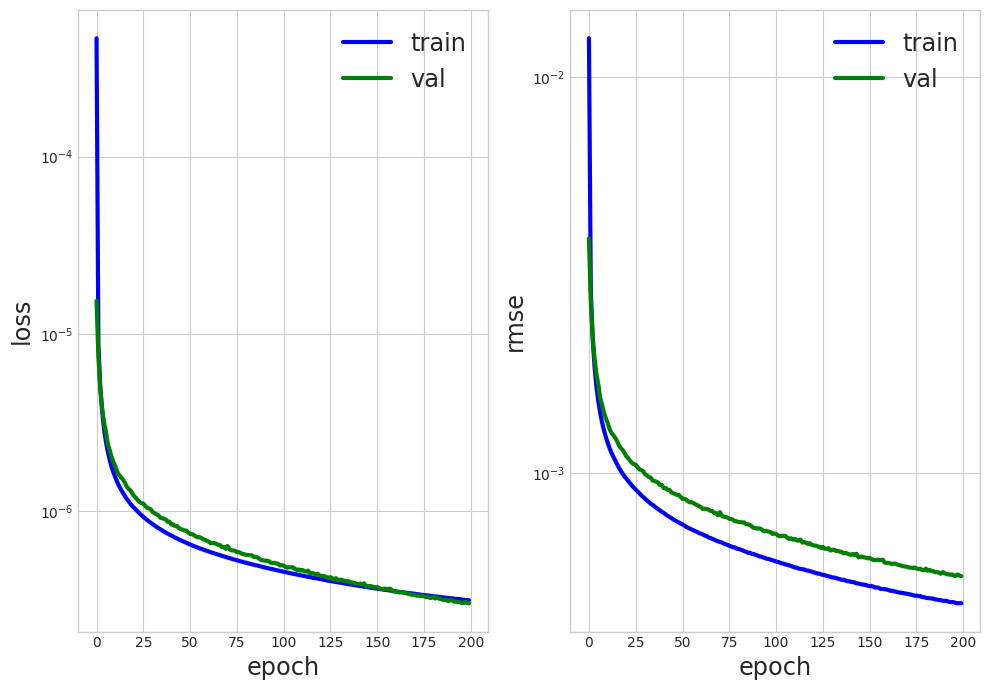

In [20]:
metrics = chonknoris.parse_metrics("%s/%s/csv/metrics.csv"%(save_dir,name))
chonknoris.plot_metrics(metrics,linewidth=3,color_train="b",color_val="g")
metrics.iloc[::max(1,len(metrics)//8)]

### Inference

In [21]:
with chonknoris.TorchNumThreadsContext(1):
    print("NK")
    vs_v_nk,data_v_nk = pde_solve(u_v,num_newton_iter=4,relaxation=0.,line_search=False,laplace_wraparound=False,deriv_wraparound=False,store_Linvs=False,vref=vs_v[:,:,-1,:].to(DEVICE),verbose=5,vverbose=30)
    

NK
    time step 30 of 151: t = 0.19           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 5.62e-04  | 4.47e-03     2.04e-02     2.51e-02     6.27e-02     | 1.17e-02     2.44e-02     2.71e-02     5.00e-02     |
        4              | 1.12e-03  | 4.72e-17     1.09e-16     1.11e-16     1.94e-16     | 9.49e-17     1.63e-16     1.64e-16     2.45e-16     |
    time step 60 of 151: t = 0.39           
    ----------------------------------------
        iter of 4      | time      | RMSE residual                                       | L

In [33]:
line_search = True
lr = 1.
verbose = 1
vverbose = 25
num_newton_iter = 15
assert len(relaxations)==1, "not sure how to set relaxation for reference solver if there are multiple relaxations"
nn_Linv_mlp = nn_Linv_mlp.to(DEVICE)
models = {
    "MLP":torch.compile(nn_Linv_mlp),
}
vs_v_chonknoris = {}
data_v_chonknoris = {}
#vs_v_chonknoris_ig = {}
#data_v_chonknoris_ig = {}
for name,model in models.items():
    def predict_Linvs(vs):
        Linvs_hat_sparse = torch.zeros((vs.size(0),Nx,Nx),device=DEVICE)
        with torch.no_grad(), torch.inference_mode():
            Linvs_hat_sparse_flat_v = model(vs)
        Linvs_hat_sparse[:,ds_Linv_t._lti0,ds_Linv_t._lti1] = Linvs_hat_sparse_flat_v
        Linvs_hat_sparse = Linvs_hat_sparse[:,perm_inv]
        # diag = Linvs_hat_sparse[:,torch.arange(N),torch.arange(N)]
        # diag[diag<0] = 0
        # Linvs_hat_sparse[:,torch.arange(N),torch.arange(N)] = diag
        return Linvs_hat_sparse
    with chonknoris.TorchNumThreadsContext(1):
        print("%s CHONKNORIS"%name)
        vs_v_chonknoris[name],data_v_chonknoris[name] = pde_solve(u_v,predict_Linvs=predict_Linvs,num_newton_iter=num_newton_iter,relaxation=0.,line_search=line_search,store_Linvs=False,vref=vs_v[:,:,-1,:].to(DEVICE),verbose=verbose,vverbose=vverbose)
        # print("%s CHONKNORIS + IG"%name) 
        # vs_v_chonknoris_ig[name],data_v_chonknoris_ig[name] = pde_solve(u_v,v0_pred=v0_pred,predict_Linvs=predict_Linvs,num_newton_iter=num_newton_iter,relaxation=0.,line_search=line_search,store_Linvs=False,vref=vs_v[:,:,-1,:],verbose=verbose,vverbose=vverbose)


MLP CHONKNORIS
    time step 25 of 151: t = 0.16           
    ----------------------------------------
        iter of 15     | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 7.84e-04  | 4.78e-03     2.24e-02     2.86e-02     7.27e-02     | 1.21e-02     2.54e-02     2.86e-02     5.61e-02     |
        1              | 2.20e-03  | 3.87e-05     3.74e-04     1.12e-03     4.81e-03     | 1.01e-04     3.42e-04     6.78e-04     2.77e-03     |
        2              | 2.05e-03  | 3.08e-07     6.04e-06     9.14e-05     4.53e-04     | 8.40e-07     5.48e-06     4.83e-05     2.93e-04     |
        3              | 

In [34]:
torch.save(
    {
        "xticks": xticks,
        "data_v_chonknoris": data_v_chonknoris,
        "tticks": tticks, 
        "xmesh": xmesh, 
        "tmesh": tmesh, 
        "data_v_nk": data_v_nk
    },
    ROOT+"/out/data_final_plot.burgers_1d.pt")

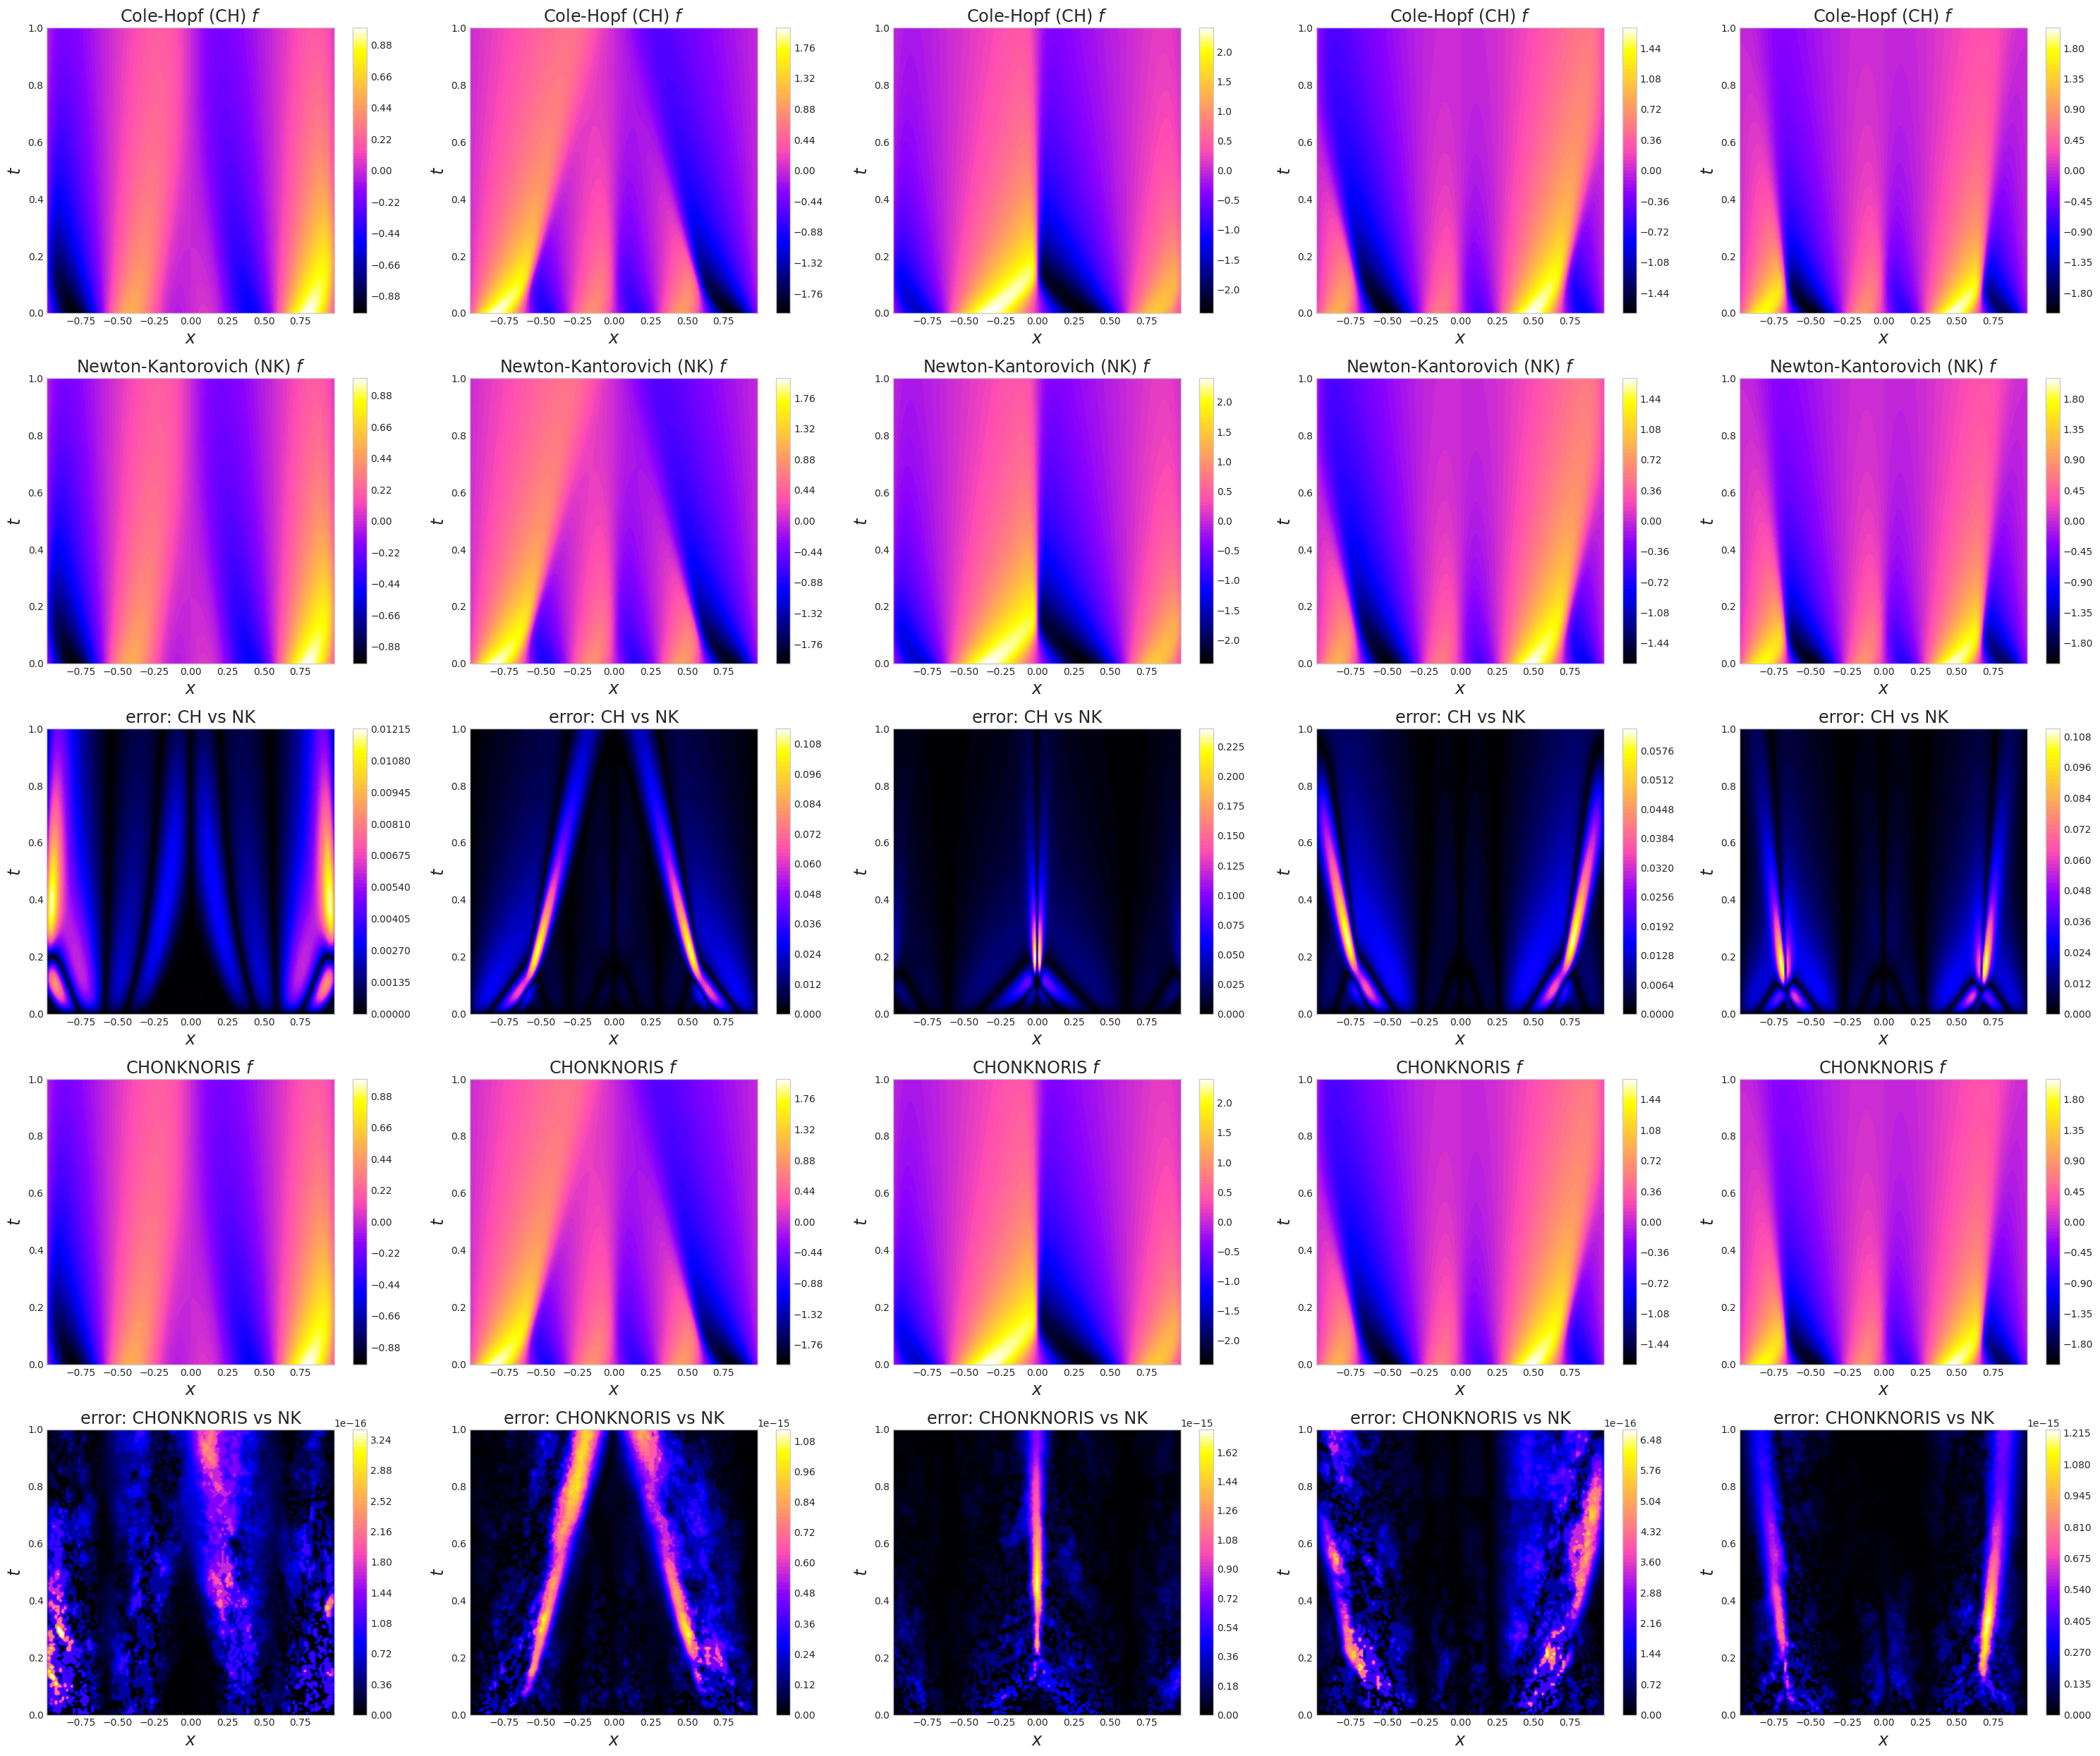

In [35]:
SHOWIDXS = [1,2,3,6,8]
name = "MLP"
fig,ax = chonknoris.plot_contourfs(
    data = [
        [(xmesh,tmesh,vref[vidx[i]]) for i in SHOWIDXS],
        [(xmesh,tmesh,vs_v_nk[i,:,-1,:]) for i in SHOWIDXS],
        [(xmesh,tmesh,torch.abs(vref[vidx[i]]-vs_v_nk[i,:,-1,:])) for i in SHOWIDXS],
        [(xmesh,tmesh,vs_v_chonknoris[name][i,:,-1,:]) for i in SHOWIDXS],
        [(xmesh,tmesh,torch.abs(vs_v_chonknoris[name][i,:,-1,:]-vs_v_nk[i,:,-1,:])) for i in SHOWIDXS],
    ],
    xlabels = r"$x$",
    ylabels = r"$t$",
    titles = [[r"Cole-Hopf (CH) $f$"],[r"Newton-Kantorovich (NK) $f$"],["error: CH vs NK"],[r"CHONKNORIS $f$"],["error: CHONKNORIS vs NK"]],
    cmap = cm.gnuplot2,
)
fig.savefig("out/CHONKNORIS_error.png",dpi=256)

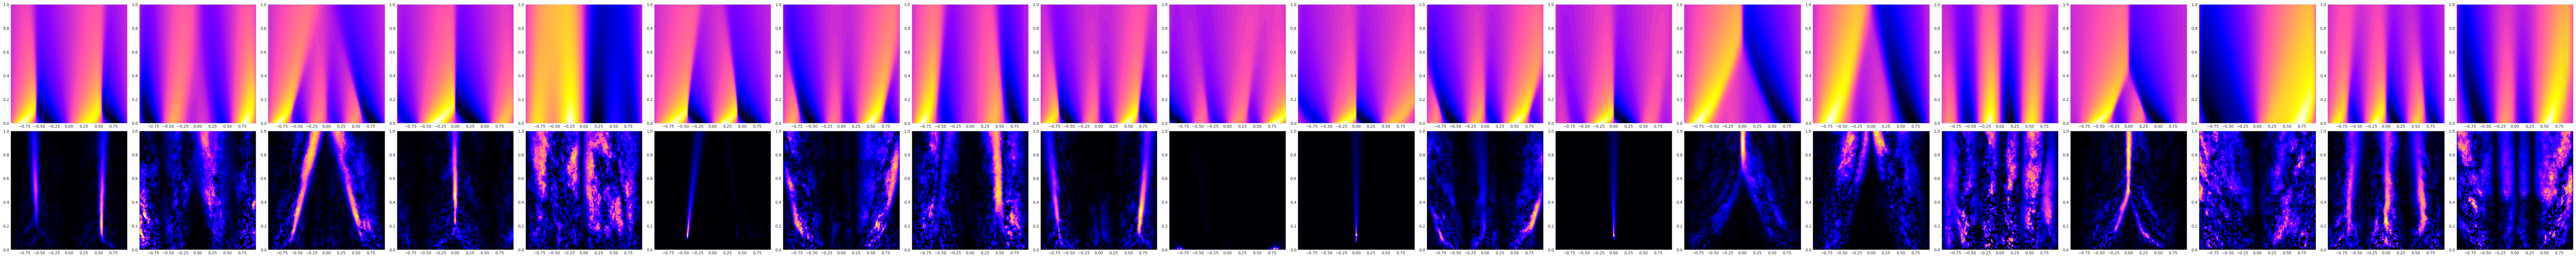

In [36]:
SHOWIDXS = [1,2,3,6,8]
name = "MLP"
ncols = 20
levels = 100
fig,ax = pyplot.subplots(nrows=2,ncols=ncols,figsize=(4.5*ncols,4.5*2))
for i in range(ncols):
    ax[0,i].contourf(xmesh,tmesh,vs_v_chonknoris[name][i,:,-1,:],cmap=cm.gnuplot2,levels=levels,antialiased=False)
    ax[1,i].contourf(xmesh,tmesh,torch.abs(vs_v_chonknoris[name][i,:,-1,:]-vs_v_nk[i,:,-1,:]),levels=levels,cmap=cm.gnuplot2)
for i in range(ax.shape[0]): 
    for j in range(ax.shape[1]):
        ax[i,j].set_aspect(2)
fig.tight_layout()

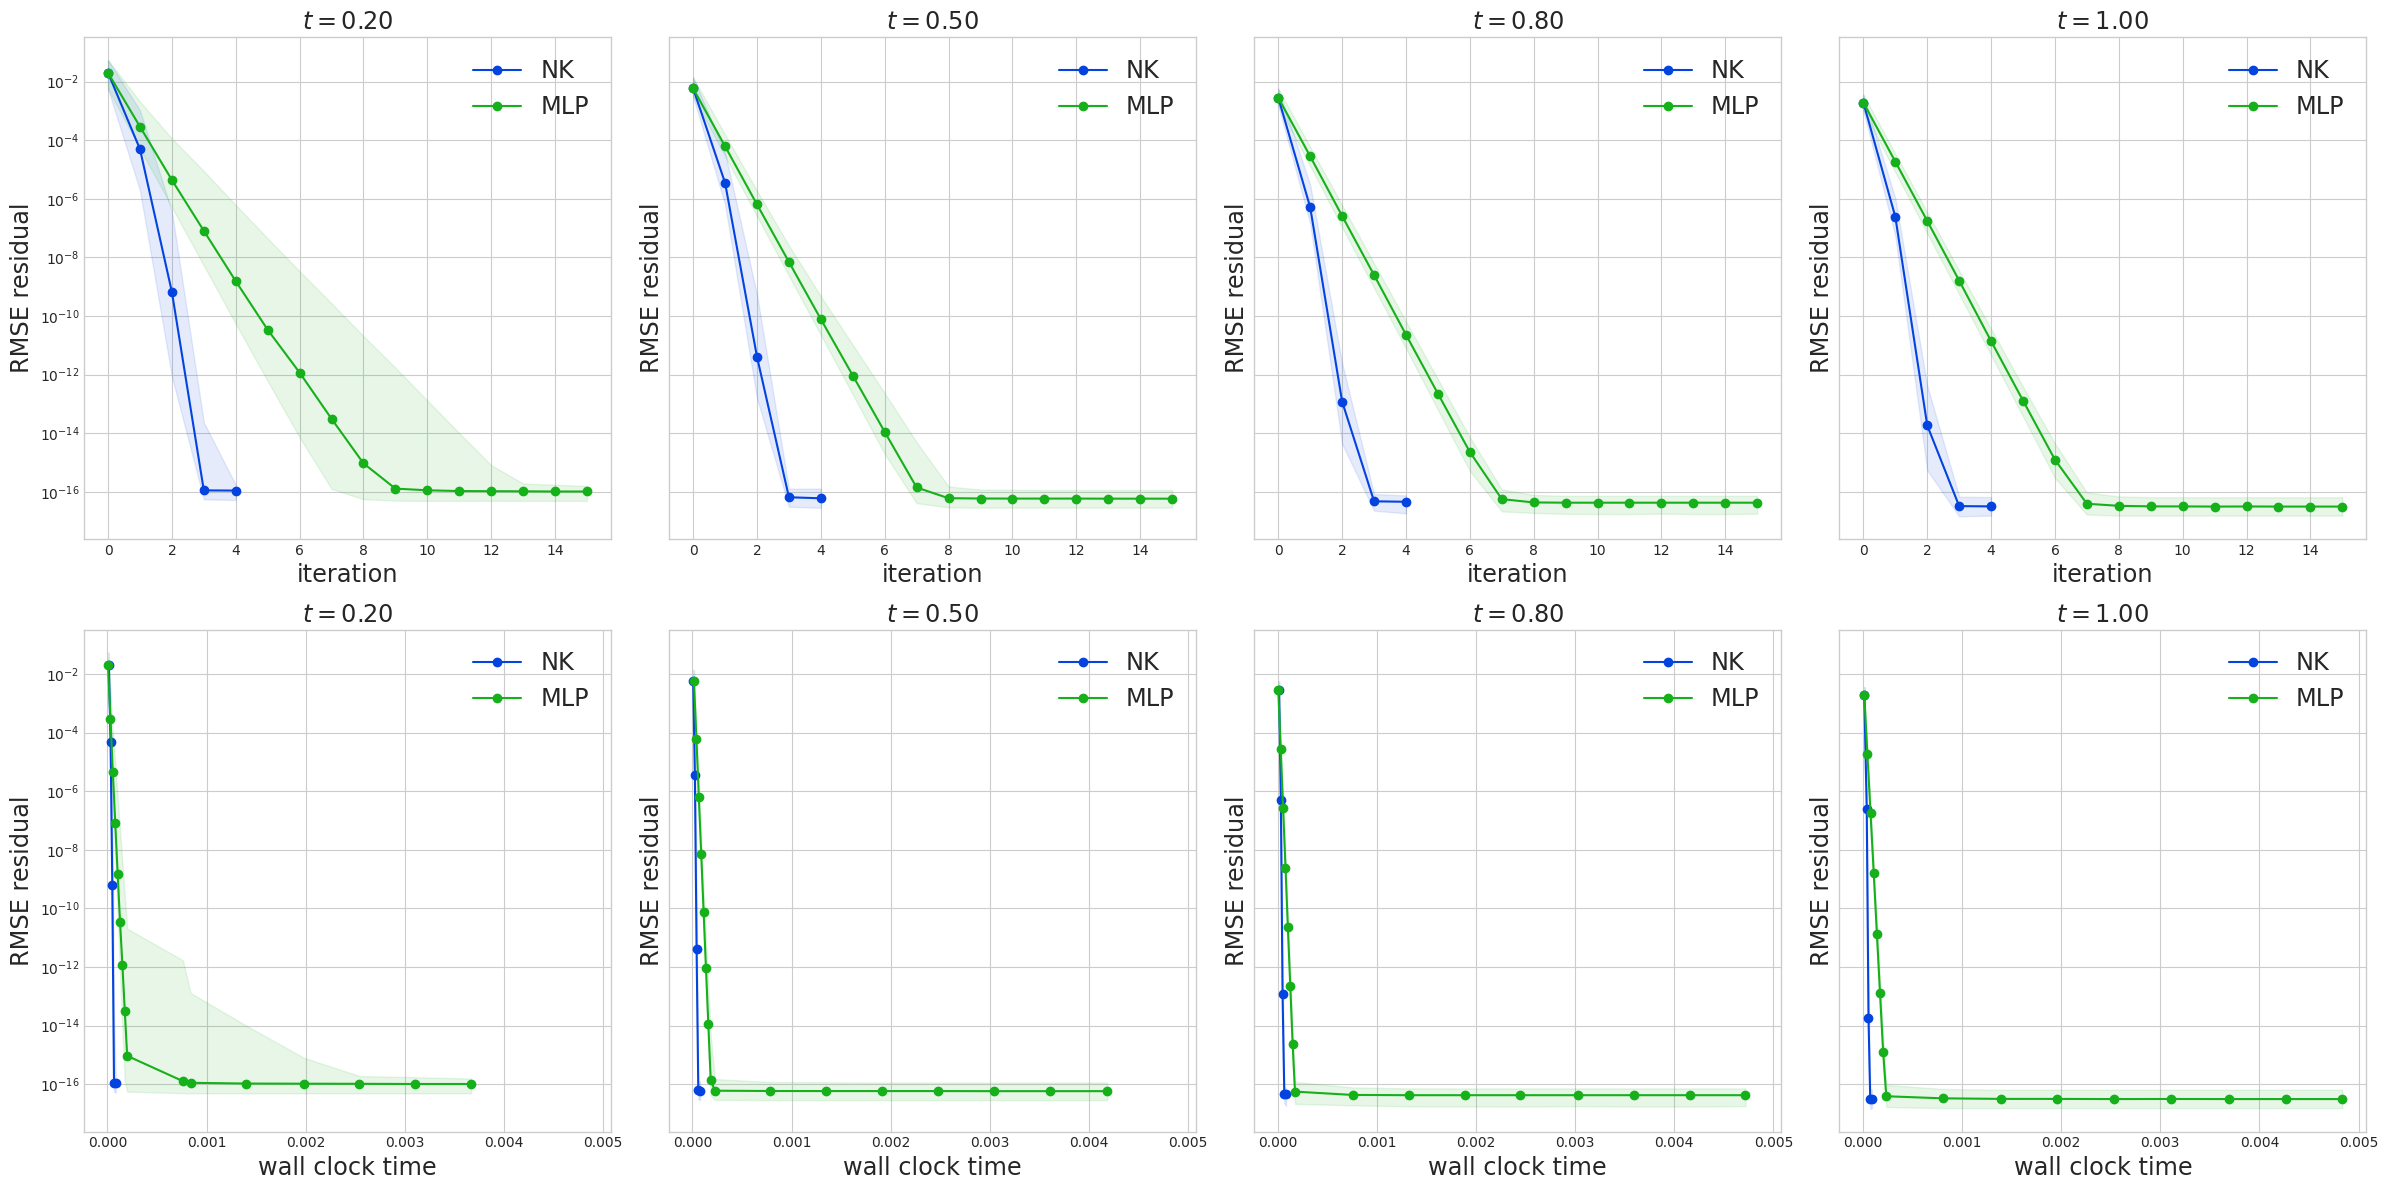

In [37]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [
                (None,data_v_nk["rmse_resid"][:,tiplt,:],"NK"),
                # (None,data_v_chonknoris["GPR"]["rmse_resid"][:,tiplt,:],"GPR"),
                (None,data_v_chonknoris["MLP"]["rmse_resid"][:,tiplt,:],"MLP"),
                #(None,data_v_ig["rmse_resid"][:,tiplt,:],"MLP IG"),
                #(None,data_v_chonknoris_ig["rmse_resid"][:,tiplt,:],"CHONKNORIS IG"),
            ]
        for tiplt in tpltidxs],
        [
            [
                (data_v_nk["times"][tiplt]-data_v_nk["times"][tiplt-1,-1],data_v_nk["rmse_resid"][:,tiplt,:],"NK"),
                # (data_v_chonknoris["GPR"]["times"][tiplt]-data_v_chonknoris["GPR"]["times"][tiplt-1,-1],data_v_chonknoris["GPR"]["rmse_resid"][:,tiplt,:],"GPR"),
                (data_v_chonknoris["MLP"]["times"][tiplt]-data_v_chonknoris["MLP"]["times"][tiplt-1,-1],data_v_chonknoris["MLP"]["rmse_resid"][:,tiplt,:],"MLP"),
                #(data_v_ig["times"][tiplt]-data_v_ig["times"][tiplt-1,-1],data_v_ig["rmse_resid"][:,tiplt,:],"MLP IG"),
                #(data_v_chonknoris_ig["times"][tiplt]-data_v_chonknoris_ig["times"][tiplt-1,-1],data_v_chonknoris_ig["rmse_resid"][:,tiplt,:],"CHONKNORIS IG"),
            ]
        for tiplt in tpltidxs],
    ],
    xlabels = [["iteration"],["wall clock time"]],
    ylabels = "RMSE residual",
    colors=COLORS,
    qhighs=[.90],
    qlows=[.1],
    #plt_band_alphas=[],
    xlogscale=False,
    ylogscale=True,
    sharex="row",
    sharey=True,
    titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
)
fig.savefig("out/CHONKNORIS_convergence.pdf")

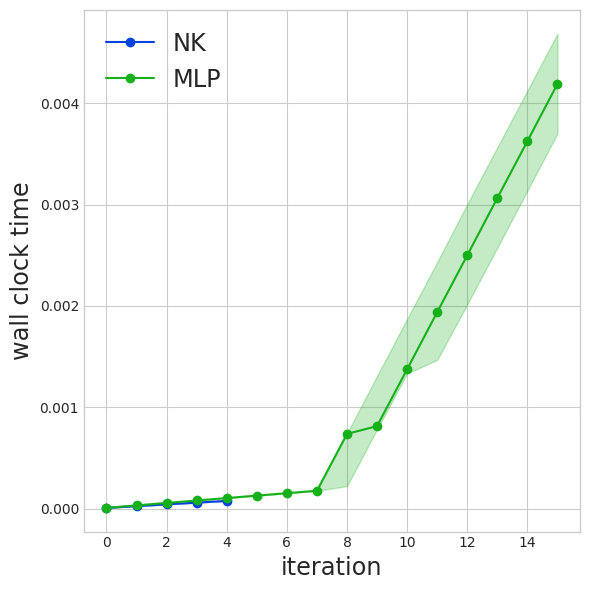

In [38]:
tpltidxs = [Nt//5,Nt//2,4*Nt//5,Nt-1]
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [
                (None,data_v_nk["times"][1:]-data_v_nk["times"][:-1,-1,None],"NK"),
                # (None,data_v_ig["times"][1:]-data_v_ig["times"][:-1,-1,None],"IG"),
                (None,data_v_chonknoris["MLP"]["times"][1:]-data_v_chonknoris["MLP"]["times"][:-1,-1,None],"MLP"),
                # (None,data_v_chonknoris["GPR"]["times"][1:]-data_v_chonknoris["GPR"]["times"][:-1,-1,None],"GPR"),
            ]
        ],
    ],
    xlabels = "iteration",
    ylabels = "wall clock time",
    colors=COLORS,
    qhighs=[.75],
    qlows=[.25],
    plt_band_alphas=[.25],
    xlogscale=False,
    ylogscale=False,
    plot_mean=False,
    plot_median=True,
    #sharex=True,
    #sharey="row",
    #titles = [r"$t = %.2f$"%tticks[tiplt] for tiplt in tpltidxs],
)

## Timing Comparisonm

In [39]:
N_times_comp = 8

In [41]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris_model = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        models["MLP"](torch.rand(1,127,device=DEVICE))
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris_model[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris_model")
    print(times_chonknoris_model) 
    print("times_chonknoris_model.median() = %.1e"%times_chonknoris_model.median())

times_chonknoris_model
tensor([0.0006, 0.0003, 0.0002, 0.0002, 0.0002, 0.0002, 0.0003, 0.0002])
times_chonknoris_model.median() = 2.3e-04


In [42]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = pde_solve(u_v[[i]],predict_Linvs=predict_Linvs,num_newton_iter=num_newton_iter,relaxation=0.,line_search=line_search,store_Linvs=False,vref=vs_v[[i],:,-1,:].to(DEVICE),verbose=verbose,vverbose=vverbose)
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris")
    print(times_chonknoris) 
    print("times_chonknoris.median() = %.1e"%times_chonknoris.median())

    time step 25 of 151: t = 0.16           
    ----------------------------------------
        iter of 15     | time      | RMSE residual                                       | L2 relative error                                   |
                       |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
        ----------------------------------------------------------------------------------------------------------------------------------------
        0              | 7.58e-04  | 2.34e-02     2.34e-02     2.34e-02     2.34e-02     | 2.22e-02     2.22e-02     2.22e-02     2.22e-02     |
        1              | 1.88e-03  | 7.30e-04     7.30e-04     7.30e-04     7.30e-04     | 5.30e-04     5.30e-04     5.30e-04     5.30e-04     |
        2              | 1.73e-03  | 3.71e-05     3.71e-05     3.71e-05     3.71e-05     | 2.67e-05     2.67e-05     2.67e-05     2.67e-05     |
        3              | 1.72e-03  | 2.3